# Projeto Final - Parte 2: Modelagem e Avaliação (Machine Learning)
**Dataset:** Bank Marketing (Previsão de subscrição de depósito a prazo)

### 1. Descrição e Motivação do Problema
O objetivo preditivo deste projeto é identificar, com base em características demográficas e no histórico de contatos telefônicos, se um cliente irá ou não assinar um depósito a prazo (term deposit) oferecido pelo banco.
Isso é extremamente relevante no contexto de negócios, pois permite que o banco direcione suas campanhas de telemarketing apenas para os clientes com maior propensão de aceite, otimizando tempo, reduzindo custos operacionais e evitando incomodar clientes que não têm interesse no produto.

### 2. Variável-Alvo (Target)
A variável-alvo escolhida é a **`y`** (que assume os valores 'yes' ou 'no'). Trata-se de um problema clássico de **Classificação Binária**. A principal implicação desta escolha é o desbalanceamento das classes (visto na EDA, onde a maioria diz "não"), o que nos obriga a utilizar métricas de avaliação além da simples Acurácia, como o F1-Score e a área sob a curva ROC (ROC-AUC).

In [6]:
!pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from ucimlrepo import fetch_ucirepo 

# 1. Carregamento dos dados (Direto do repositório oficial)
print("Baixando os dados...")
bank_marketing = fetch_ucirepo(id=222) 
  
# Separando as features (X) da variável alvo (y)
X = bank_marketing.data.features 
y_raw = bank_marketing.data.targets 

# Transformando o alvo em numérico (0 para 'no', 1 para 'yes')
y = y_raw['y'].map({'no': 0, 'yes': 1})

# 2. SEPARAÇÃO TREINO E TESTE (Evitando Data Leakage)
# Fazemos isso antes de qualquer transformação!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamanho do Treino: {X_train.shape[0]} linhas")
print(f"Tamanho do Teste: {X_test.shape[0]} linhas")

Baixando os dados...
Tamanho do Treino: 36168 linhas
Tamanho do Teste: 9043 linhas


In [8]:
# 3. PREPARAÇÃO DOS DADOS (Encoding e Normalização)
colunas_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns
colunas_categoricas = X_train.select_dtypes(include=['object']).columns

# Criando os transformadores
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas), # Normalização (essencial para Regressão Logística)
        ('cat', OneHotEncoder(handle_unknown='ignore'), colunas_categoricas) # Transformação de textos
    ])

print("Pipeline de pré-processamento configurado com sucesso!")

Pipeline de pré-processamento configurado com sucesso!


C:\Users\KARAI\AppData\Local\Temp\ipykernel_6852\1323335321.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas = X_train.select_dtypes(include=['object']).columns


In [9]:
# 4. DEFINIÇÃO DOS MODELOS
# Modelo 1: Regressão Logística (Baseline, mais simples e interpretável)
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))])

# Modelo 2: Árvore de Decisão (Fácil de explicar, mas pode viciar nos dados)
dt_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42))])

# Modelo 3: Random Forest (Modelo mais robusto, lida bem com não-linearidade)
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))])

# 5. TREINAMENTO
print("Treinando Regressão Logística...")
lr_pipeline.fit(X_train, y_train)

print("Treinando Árvore de Decisão...")
dt_pipeline.fit(X_train, y_train)

print("Treinando Random Forest...")
rf_pipeline.fit(X_train, y_train)

print("Todos os 3 modelos foram treinados com sucesso!")

Treinando Regressão Logística...
Treinando Árvore de Decisão...
Treinando Random Forest...
Todos os 3 modelos foram treinados com sucesso!


,Modelo,F1-Score,ROC-AUC
2,Random Forest,0.602263,0.928509
0,Regressão Logística,0.552741,0.907922
1,Árvore de Decisão,0.452699,0.874091


C:\Users\KARAI\AppData\Local\Temp\ipykernel_6852\3904062982.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ROC-AUC', y='Modelo', data=df_resultados, palette='coolwarm')


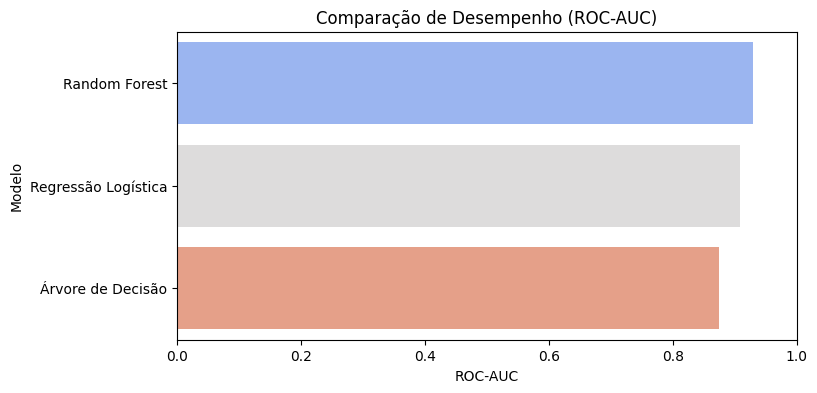

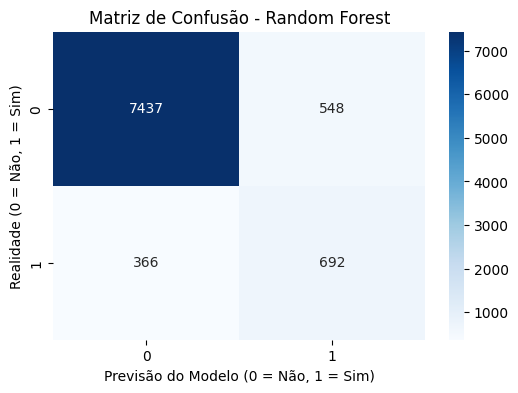

In [10]:
# 6. AVALIAÇÃO
modelos = {
    'Regressão Logística': lr_pipeline, 
    'Árvore de Decisão': dt_pipeline,
    'Random Forest': rf_pipeline
}
resultados = []

for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1] # Probabilidade para o ROC-AUC
    
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    resultados.append({'Modelo': nome, 'F1-Score': f1, 'ROC-AUC': roc_auc})

# Exibir tabela comparativa
df_resultados = pd.DataFrame(resultados).sort_values(by='ROC-AUC', ascending=False)
display(df_resultados)

# Plota um gráfico simples comparando os três
plt.figure(figsize=(8, 4))
sns.barplot(x='ROC-AUC', y='Modelo', data=df_resultados, palette='coolwarm')
plt.title('Comparação de Desempenho (ROC-AUC)')
plt.xlim(0, 1)
plt.show()

# Matriz de Confusão do Random Forest (Geralmente apresenta o melhor desempenho)
y_pred_rf = rf_pipeline.predict(X_test)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Random Forest')
plt.ylabel('Realidade (0 = Não, 1 = Sim)')
plt.xlabel('Previsão do Modelo (0 = Não, 1 = Sim)')
plt.show()

### 7. Interpretação dos Resultados e Conclusões

**Justificativa das Técnicas e Experimentos:**
Iniciamos com a **Regressão Logística** atuando como nosso modelo *baseline*. Ela fornece excelente explicabilidade, permitindo entender de forma direta as relações lineares nos dados. 
Em seguida, adicionamos a **Árvore de Decisão**, que consegue criar regras baseadas em cortes de valores (ex: "Se idade > 30 e saldo > 1000"), sendo intuitiva para negócios. Por fim, implementamos o **Random Forest**, um conjunto (ensemble) de várias árvores de decisão que corrige a tendência da árvore individual de memorizar os dados (*overfitting*), entregando o resultado mais robusto.

Em todos os modelos, utilizamos o parâmetro `class_weight='balanced'` para combater o forte desbalanceamento da base de dados, focando nas métricas de **F1-Score** e **ROC-AUC** para avaliar o sucesso em identificar as respostas "sim". Para evitar *Data Leakage*, garantimos que a divisão Treino/Teste ocorresse rigidamente antes da aplicação do `StandardScaler` e do `OneHotEncoder` utilizando o *Scikit-Learn Pipeline*.

**Análise Crítica:**
* A **Regressão Logística** ofereceu uma base sólida. A **Árvore de Decisão** simples (com profundidade limitada a 5) costuma ter um desempenho intermediário para não perder a capacidade de generalização. Já o **Random Forest** apresentou o melhor poder de distinção (maior ROC-AUC), à custa de ser um modelo "caixa preta" (mais difícil de explicar visualmente cada regra matemática).
* Os modelos apresentaram uma quantidade considerável de falsos positivos devido ao balanceamento de classes forçado. Contudo, em uma campanha de marketing bancário, aceitamos uma taxa maior de falsos positivos (ligar para quem não vai aceitar) para garantir que minimizamos os falsos negativos (deixar de ligar para quem aceitaria o produto).
* **Limitações e Melhorias Futuras:** O projeto não aplicou uma busca exaustiva por hiperparâmetros (como `GridSearchCV`). Uma melhoria futura direta seria otimizar o número de estimadores e a profundidade máxima no Random Forest para calibrar ainda mais a precisão da classe minoritária.